In [2]:
import numpy as np
import pandas as pd
import hist
from hist import Hist
import awkward as ak
import json
import uproot
import math
from coffea import util
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

In [36]:
out_dir = "../outfiles/Run3Summer22EE/cutflow"

era = "Run3Summer22EE"
        
lumis = {
    "Run3Summer22EE" : 581.42,
}

# Table of contents <a class="anchor" id="toc"></a>

* [Plot pass/fail](#plot)

(0.0, 40726.35097512967)

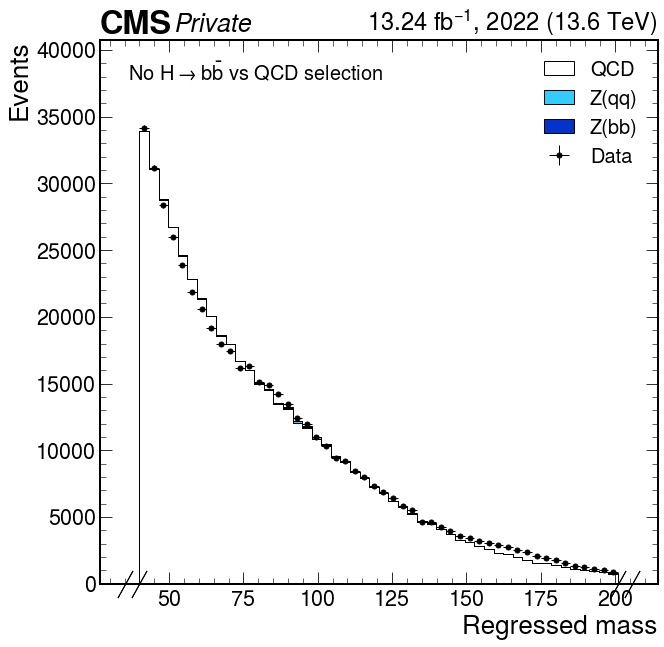

In [33]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
data = pickle.load(open(f'{out_dir}/data.pkl','rb'))

colour = {
    "QCD" : "white",
    "Z(bb)" : "#0033cc",
    "Z(qq)" : "#33ccff",
#     "W" : "#cccccc",
    "Bkg. H" : "#ffcc00",
}

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 1
    
hs = []
labels = []
colours = []

fig, (ax) = plt.subplots(
    1, 1, figsize=(10, 10), #gridspec_kw={"height_ratios": (3, 1)}, sharex=True
)
fig.subplots_adjust(hspace=0.1)
ax.set_ylabel("Events")
#     rax.set_ylabel("Data / MC")
#     rax.set_xlabel("Regressed mass")
#     ax.set_xlabel(" ")

for process in colour.keys():

    h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")[
        :, 0, :, 0:len:sum, :, 0:len:sum
    ]
    if process[0] == "Z":
        if process == "Z(bb)":
            h = h[:, hist.loc("ZJets"), 3:4:sum]
        else:
            h = h[:, hist.loc("ZJets"), 1:3:sum]
    else:
        h = h[:, hist.loc(process), 0:len:sum]

    h = h / 55    
        
    hs.append(h)
    labels.append(process)
    colours.append(colour[process])

mplhep.histplot(
    hs,
    ax=ax,
    label=labels,
    stack=True,
    sort="y_r",
    color=colours,
    histtype="fill",
    edgecolor="black",
    linewidth=1,
)

h = data.project("reg", "cut", "process", "disc", "genflav", "pt")[
    :, 0, hist.loc("Run3Summer22EE"), 0:len:sum, 0:len:sum, 0:len:sum
]

mplhep.histplot(
    h, 
    ax=ax, 
    histtype="errorbar",
    xerr=True,
    c="black",
    label=f"Data"
)

plt.text(0.05, 0.92, r"No $H\rightarrow b\bar{b}$ vs QCD selection",
            fontsize=20,
            horizontalalignment='left',
            verticalalignment='bottom',
            transform=ax.transAxes
           )

mplhep.cms.label(
        ax=ax, 
        data=True, 
        fontsize=25,
        label="Private",
        year=2022,
        lumi=f"{lumis[era]/1000:.2f}",
        com=13.6,
        )

ax.legend(loc="upper right", fontsize=20)

ax.set_ylim(0, max(hs[0].values()) * 1.2)

# Plot pass/fail <a class="anchor" id="plot"></a>
[TOC](#toc)

QCD (tight)
Sig eff.: 0.4 % (pass: 7298)
Z(bb) (tight)
Sig eff.: 33.2 % (pass: 399)
Z(qq) (tight)
Sig eff.: 1.1 % (pass: 83)
W (tight)
Sig eff.: 0.8 % (pass: 290)
Bkg. H (tight)
Sig eff.: 12.3 % (pass: 23)


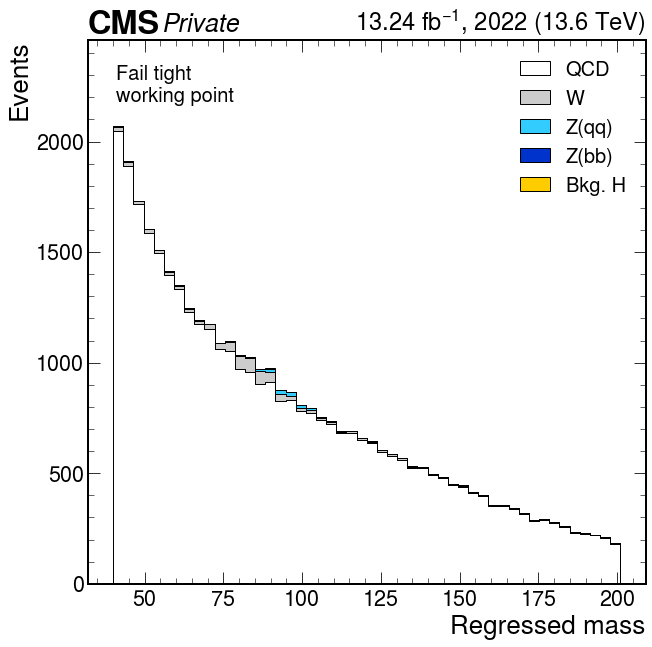

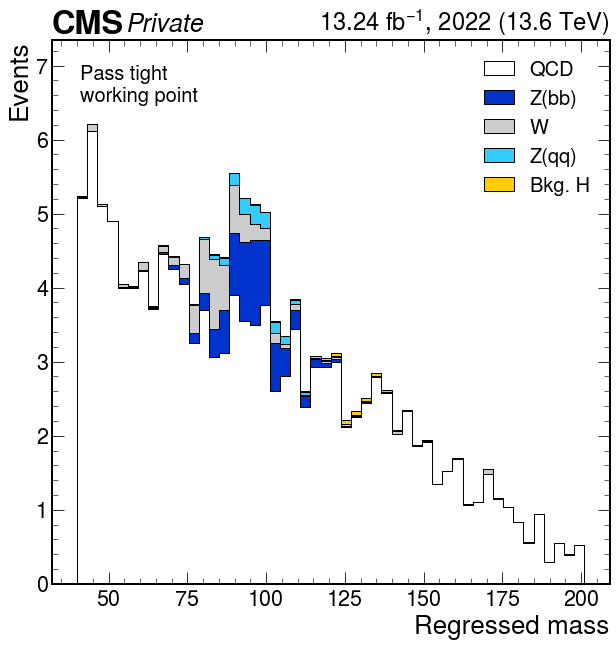

In [7]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
data = pickle.load(open(f'{out_dir}/data.pkl','rb'))

colour = {
    "QCD" : "white",
    "Z(bb)" : "#0033cc",
    "Z(qq)" : "#33ccff",
    "W" : "#cccccc",
    "Bkg. H" : "#ffcc00",
}

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 3

for region in ["Fail", "Pass"]:
    
    hs = []
    labels = []
    colours = []
    
    fig, (ax) = plt.subplots(
        1, 1, figsize=(10, 10), #gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events")
#     rax.set_ylabel("Data / MC")
#     rax.set_xlabel("Regressed mass")
#     ax.set_xlabel(" ")

    for process in colour.keys():
        
        h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")
        
        if process[0] == "Z":
            if process == "Z(bb)":
                h = h[:, 5, hist.loc("ZJets"), :, 3:4:sum, 0:len:sum]
            else:
                h = h[:, 5, hist.loc("ZJets"), :, 1:3:sum, 0:len:sum]
        else:
            h = h[:, 5, hist.loc(process), :, 0:len:sum, 0:len:sum]
        
        if "Pass" in region:
            print(f"{process} ({wps[wp]})")
            print(f"Sig eff.: {h[:, wp:4:sum].sum().value/h.sum().value * 100:.1f} % (pass: {h[:, wp:4:sum].sum().value:.0f})")
            h = h[:, wp:4:sum]
            h = h / 55
        else:
            h = h[:, 0:wp:sum]
            h = h / 55
            
        hs.append(h)
        labels.append(process)
        colours.append(colour[process])

    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
        sort="y_r",
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
    )
            
#     h = data.project("reg", "cut", "process", "disc", "genflav", "pt")[:, 5, hist.loc("Run3Summer22EE"), :, 0:len:sum, 0:len:sum]
    
#     if "Pass" in region:
#         print(f"Data: ({wps[wp]})")
#         print(f"Sig eff.: {h[:, wp:4:sum].sum().value/h.sum().value * 100:.1f} % (pass: {h[:, wp:4:sum].sum().value:.0f})")
#         h = h[:, wp:4:sum]
#     else:
#         h = h[:, 0:wp:sum]

#     mplhep.histplot(
#         h, 
#         ax=ax, 
#         histtype="errorbar",
#         xerr=True,
#         c="black",
#         label=f"Data"
#     )

    plt.text(0.05, 0.88, f"{region} {wps[wp]}\nworking point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumis[era]/1000:.2f}",
            com=13.6,
            )
    
    ax.legend(loc="upper right", fontsize=20)
    
    ax.set_ylim(0, max(hs[0].values()) * 1.2)

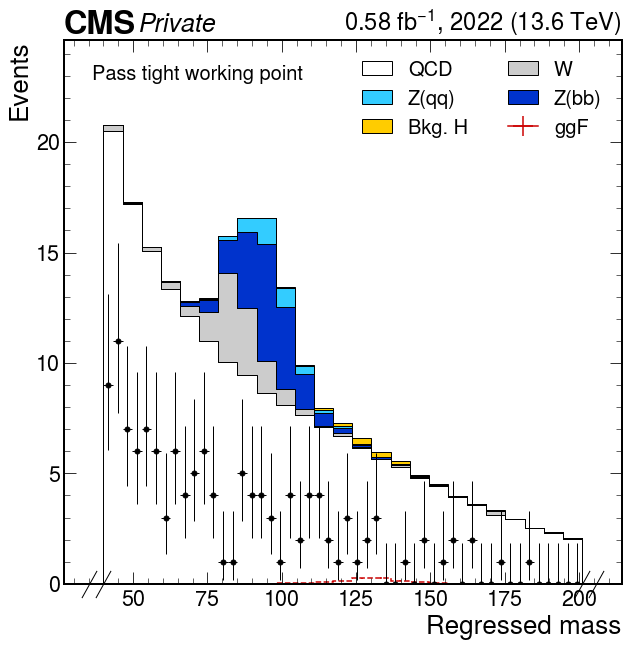

In [38]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
data = pickle.load(open(f'{out_dir}/data.pkl','rb'))

colour = {
    "QCD" : "white",
    "W" : "#cccccc",
    "Z(bb)" : "#0033cc",
    "Z(qq)" : "#33ccff",
    "Bkg. H" : "#ffcc00",
}

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 3

for region in ["Pass"]:
    
    hs = []
    labels = []
    colours = []
    
    fig, (ax) = plt.subplots(
        1, 1, figsize=(10, 10), #gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events")
#     rax.set_ylabel("Data / MC")
#     rax.set_xlabel("Regressed mass")
#     ax.set_xlabel(" ")

    for process in colour.keys():
        
        h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")[{"reg" : hist.rebin(2)}]
        
        if process[0] == "Z":
            if process == "Z(bb)":
                h = h[:, 5, hist.loc("ZJets"), :, 3:4:sum, 0:len:sum]
            else:
                h = h[:, 5, hist.loc("ZJets"), :, 1:3:sum, 0:len:sum]
                
            h = h[:, wp:4:sum]
        elif process == "QCD":
            h = h[:, 5, hist.loc(process), :, 0:len:sum, 0:len:sum]
        
            h = h[:, 0:wp:sum]
            h = h * 0.0021556286577087197
        else:
            h = h[:, 5, hist.loc(process), wp:4:sum, 0:len:sum, 0:len:sum]
        
            
        hs.append(h)
        labels.append(process)
        colours.append(colour[process])

    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
#         sort="y_r",
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
    )
    
    h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")[
        :, 5, hist.loc("ggF"), wp:4:sum, 0:len:sum, 0:len:sum
    ][{"reg" : hist.rebin(2)}]
    
    mplhep.histplot(
        h, 
        ax=ax, 
        color="#cc0000",
        label=f"ggF",
        linestyle="dashed",
    )
    
    h = data.project("reg", "cut", "process", "disc", "genflav", "pt")[
        :, 0, hist.loc("Run3Summer22EE"), wp:4:sum, 0:len:sum, 0:len:sum
    ]
        
    mplhep.histplot(
        h, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Data"
    )

    plt.text(0.05, 0.92, f"{region} {wps[wp]} working point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumis[era]/1000:.2f}",
            com=13.6,
            )
    
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 3, 4, 1, 2, 5]
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=20, ncols=2)

#     ax.legend(loc="upper right", fontsize=20, ncols=2)
    
    ax.set_ylim(0, max(hs[0].values()) * 1.2)